In [1]:
%matplotlib inline

import sys
import yaml
import copy

import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.data.dataset import YOLODataset
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask

In [2]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [3]:
args=parser.parse_args('--deterministic'.split())

task='pose'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco8'
    data_config='../../coco8.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../../coco8-seg.yaml'
    
dataset=YOLODataset(args=args, data=data_config, task=task, img_path=data_dirpath, imgsz=640, cache=False,augment=True, 
                    hyp=DEFAULT_CFG_DICT, prefix='',rect=False,batch_size=16,stride=32,pad=0.5, single_cls=False,classes=None,
                fraction=1.,channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-pose\labels\train.cache
Scanning D:\data\ultralytics\coco8-pose\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(1, 1)
(2, 1)
(3, 1)
(1, 1)


In [4]:
from __future__ import annotations

import math
import random
from copy import deepcopy
from typing import Any

import cv2
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F

from computer_vision.yolov11_pose.data.augment import BaseMixTransform, LetterBox

img  (640, 640, 3) height 640, width 640


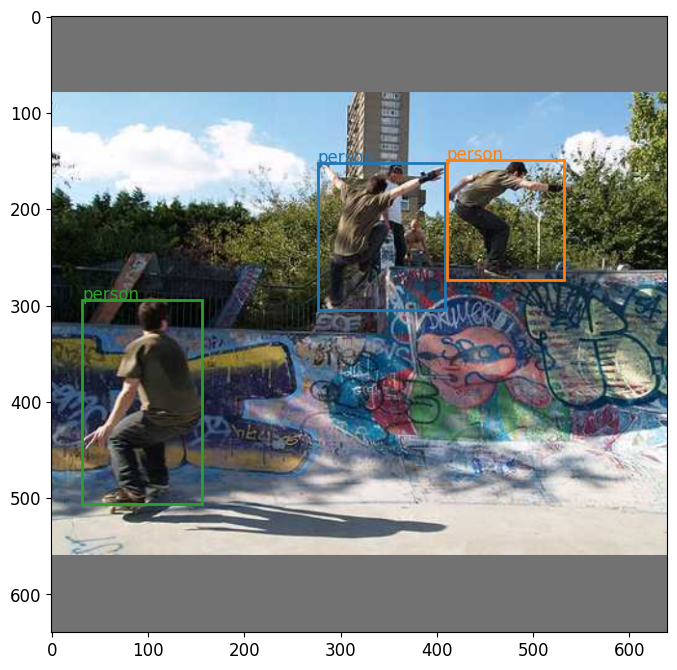

In [5]:
indx=2
labels=dataset.get_image_and_label(indx) # main label
transform=LetterBox(new_shape=(640,640), auto=False, center=True)
final_labels=transform(labels)

_, ax=plt.subplots(1,1,figsize=(20,8))

labels=final_labels
classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()]
img=labels['img']
height, width=img.shape[:2]
print('img ', img.shape, f'height {height}, width {width}')
instances=copy.deepcopy(labels['instances'])
if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
if instances.normalized: instances.denormalize()
boxes=instances.bboxes
if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
    mask=instance2mask(image=img, instance=labels['instances'])
    ax.imshow(alpha_bending(mask, img[...,::-1], 0.4))
else: ax.imshow(img[...,::-1])
for j, (box,cls) in enumerate(zip(boxes, classes)):
    # Create a Rectangle patch
    rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
    # Add the patch to the Axes
    ax.add_patch(rect)
    ax.text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

img  (640, 512, 3) height 640, width 512


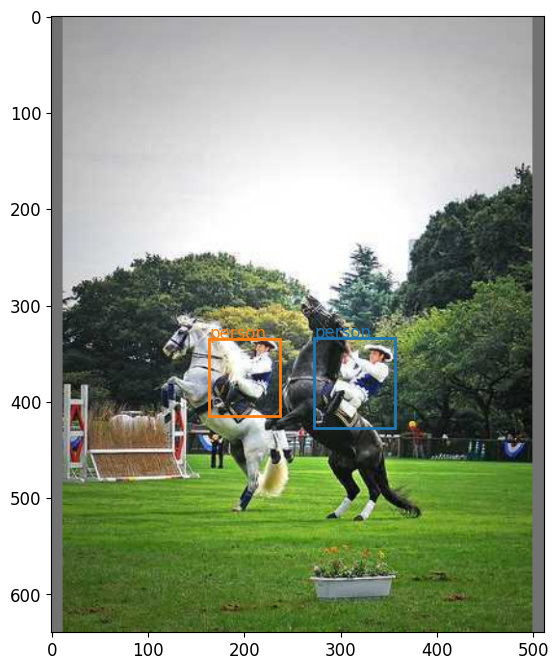

In [6]:
indx=1
labels=dataset.get_image_and_label(indx) # main label
transform=LetterBox(new_shape=(640,640), auto=True, center=True)
final_labels=transform(labels)

_, ax=plt.subplots(1,1,figsize=(20,8))

labels=final_labels
classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()]
img=labels['img']
height, width=img.shape[:2]
print('img ', img.shape, f'height {height}, width {width}')
instances=copy.deepcopy(labels['instances'])
if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
if instances.normalized: instances.denormalize()
boxes=instances.bboxes
if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
    mask=instance2mask(image=img, instance=labels['instances'])
    ax.imshow(alpha_bending(mask, img[...,::-1], 0.4))
else: ax.imshow(img[...,::-1])
for j, (box,cls) in enumerate(zip(boxes, classes)):
    # Create a Rectangle patch
    rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
    # Add the patch to the Axes
    ax.add_patch(rect)
    ax.text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)